Created dummy watermark.png


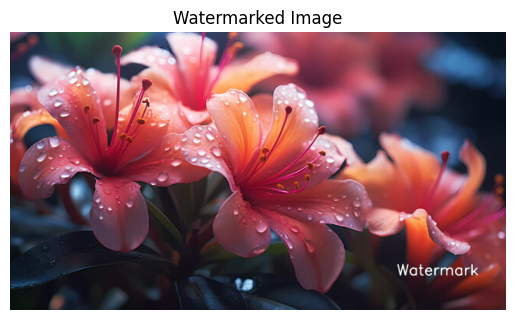

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os

# --- Start: Added code to create dummy images for demonstration ---
# Define paths for images
original_image_path = 'Flower.jpg' # Changed to Flower.jpg
watermark_path = 'watermark.png'

# Create a dummy original image if it doesn't exist
if not os.path.exists(original_image_path):
    dummy_original_image = np.zeros((300, 500, 3), dtype=np.uint8)
    cv2.putText(dummy_original_image, 'Original Image (Dummy)', (50, 150),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.imwrite(original_image_path, dummy_original_image)
    print(f"Created dummy {original_image_path}")

# Create a dummy watermark image if it doesn't exist
if not os.path.exists(watermark_path):
    dummy_watermark = np.zeros((100, 200, 4), dtype=np.uint8) # 4 channels for transparency
    cv2.putText(dummy_watermark, 'Watermark', (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255, 255), 2, cv2.LINE_AA)
    cv2.imwrite(watermark_path, dummy_watermark)
    print(f"Created dummy {watermark_path}")
# --- End: Added code ---

# Load the original image
# Replace 'original_image.jpg' with the path to your image
original_image = cv2.imread(original_image_path)

# Check if image loaded successfully
if original_image is None:
    print(f"Error: Original image at {original_image_path} not found or unable to load.")
else:
    # Load the watermark image (e.g., a logo or text)
    # Replace 'watermark.png' with the path to your watermark image
    watermark = cv2.imread(watermark_path, cv2.IMREAD_UNCHANGED)

    if watermark is None:
        print(f"Error: Watermark image at {watermark_path} not found or unable to load.")
    else:
        # Ensure the original image is 3 channels (if it's grayscale)
        if len(original_image.shape) == 2:
            original_image = cv2.cvtColor(original_image, cv2.COLOR_GRAY2BGR)

        # Resize watermark to fit a desired area (e.g., 20% of the image width)
        # This is optional, you can keep the original watermark size or define a fixed size
        watermark_width = int(original_image.shape[1] * 0.2)
        watermark_height = int(watermark.shape[0] * (watermark_width / watermark.shape[1]))
        watermark = cv2.resize(watermark, (watermark_width, watermark_height), interpolation=cv2.INTER_AREA)

        # Get dimensions of original image and watermark
        h_original, w_original = original_image.shape[:2]
        h_watermark, w_watermark = watermark.shape[:2]

        # Define the position for the watermark (e.g., bottom-right corner)
        # You can adjust these values to place the watermark anywhere
        x_offset = w_original - w_watermark - 20 # 20 pixels from right edge
        y_offset = h_original - h_watermark - 20 # 20 pixels from bottom edge

        # Ensure the watermark has an alpha channel if it's a PNG for transparency
        if watermark.shape[2] == 4:  # Check if it has 4 channels (BGRA)
            # Extract alpha channel
            alpha_channel = watermark[:, :, 3]
            # Create a 3-channel BGR image from the watermark
            watermark_bgr = watermark[:, :, :3]

            # Create a mask and inverse mask for blending
            alpha_mask = alpha_channel / 255.0
            inv_alpha_mask = 1.0 - alpha_mask

            # Get the region of interest (ROI) from the original image
            roi = original_image[y_offset:y_offset+h_watermark, x_offset:x_offset+w_watermark]

            # Apply transparency blending using NumPy operations for efficiency
            for c in range(0, 3): # Iterate over B, G, R channels
                roi[:, :, c] = (alpha_mask * watermark_bgr[:, :, c] +
                                inv_alpha_mask * roi[:, :, c])
            original_image[y_offset:y_offset+h_watermark, x_offset:x_offset+w_watermark] = roi

        else: # If watermark does not have an alpha channel, just overlay
            # This simple overlay will replace the pixels directly
            original_image[y_offset:y_offset+h_watermark, x_offset:x_offset+w_watermark] = watermark

        # Convert BGR to RGB for displaying with matplotlib
        watermarked_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

        # Display the watermarked image
        plt.imshow(watermarked_image_rgb)
        plt.title('Watermarked Image')
        plt.axis('off') # Hide axes
        plt.show()

        # Optionally, save the watermarked image
        # cv2.imwrite('watermarked_image.jpg', original_image)
